In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('C:\\Users\\HP\\Desktop\\restaurant_sales_forcasting\\data\\restaurant_sales.csv')
df.head(5)

,date,year,month,weekday,is_weekend,season,climate,is_holiday,holiday_religion,is_festival,...,is_chefspecial,dish_popularity,rating,price_per_unit,price_mean,base_low,base_mid,base_high,units_sold,revenue
0,7/22/2024,2024,7,0,0,Rainy,Rainy,0,NaN,0,...,0,7,4.45,53.23,85,30,55,80,20,1064.60
1,8/18/2023,2023,8,4,0,Rainy,Rainy,0,NaN,0,...,0,6,4.60,189.49,220,8,16,28,5,947.45
2,8/6/2024,2024,8,1,0,Rainy,Humid,0,NaN,0,...,0,6,4.38,359.65,230,6,14,26,27,9710.55
3,4/23/2023,2023,4,6,1,Summer,Hot,0,NaN,0,...,0,5,4.06,426.94,390,4,9,16,5,2134.70
4,8/3/2024,2024,8,5,1,Rainy,Rainy,0,NaN,0,...,0,6,4.56,55.41,60,42,78,115,29,1606.89


In [3]:
df.columns

Index(['date', 'year', 'month', 'weekday', 'is_weekend', 'season', 'climate',
       'is_holiday', 'holiday_religion', 'is_festival', 'working_day',
       'restaurant_id', 'restaurant_name', 'restaurant_locality',
       'restaurant_demand_multiplier', 'food_name', 'category', 'veg_nonveg',
       'ingredient', 'foodtype', 'meal_type', 'hot_cold', 'is_milkbased',
       'solid_liquid', 'spice_level', 'size', 'is_chefspecial',
       'dish_popularity', 'rating', 'price_per_unit', 'price_mean', 'base_low',
       'base_mid', 'base_high', 'units_sold', 'revenue'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 155599 entries, 0 to 155598
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          155599 non-null  str    
 1   year                          155599 non-null  int64  
 2   month                         155599 non-null  int64  
 3   weekday                       155599 non-null  int64  
 4   is_weekend                    155599 non-null  int64  
 5   season                        155599 non-null  str    
 6   climate                       149384 non-null  str    
 7   is_holiday                    155599 non-null  int64  
 8   holiday_religion              12812 non-null   str    
 9   is_festival                   155599 non-null  int64  
 10  working_day                   155599 non-null  int64  
 11  restaurant_id                 155599 non-null  str    
 12  restaurant_name               155599 non-null  str    


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') 

# Optional: for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis") 
%matplotlib inline 

df = pd.read_csv('C:\\Users\\HP\\Desktop\\restaurant_sales_forcasting\\data\\restaurant_sales.csv')
print(df.shape) 
df.head() 
df.info() 
df.describe(include='all')

(155599, 36)
<class 'pandas.DataFrame'>
RangeIndex: 155599 entries, 0 to 155598
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          155599 non-null  str    
 1   year                          155599 non-null  int64  
 2   month                         155599 non-null  int64  
 3   weekday                       155599 non-null  int64  
 4   is_weekend                    155599 non-null  int64  
 5   season                        155599 non-null  str    
 6   climate                       149384 non-null  str    
 7   is_holiday                    155599 non-null  int64  
 8   holiday_religion              12812 non-null   str    
 9   is_festival                   155599 non-null  int64  
 10  working_day                   155599 non-null  int64  
 11  restaurant_id                 155599 non-null  str    
 12  restaurant_name               155599 non-n

,date,year,month,weekday,is_weekend,season,climate,is_holiday,holiday_religion,is_festival,...,is_chefspecial,dish_popularity,rating,price_per_unit,price_mean,base_low,base_mid,base_high,units_sold,revenue
count,155599,155599.000000,155599.000000,155599.000000,155599.00000,155599,149384,155599.000000,12812,155599.000000,...,155599.000000,155599.000000,150922.000000,152480.000000,155599.000000,155599.000000,155599.000000,155599.000000,155599.000000,152480.000000
unique,730,NaN,NaN,NaN,NaN,4,6,NaN,4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,12/24/2023,NaN,NaN,NaN,NaN,Summer,Hot,NaN,Hindu,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,221,NaN,NaN,NaN,NaN,51963,31670,NaN,8329,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2023.499900,6.513834,2.999023,0.28621,NaN,NaN,0.082340,NaN,0.216325,...,0.149834,6.771155,4.508205,179.358730,173.410626,23.790545,44.012359,67.533892,71.812055,9389.935382
std,NaN,0.500002,3.446288,2.003551,0.45199,NaN,NaN,0.274883,NaN,0.411740,...,0.356910,1.172944,0.291082,122.844292,106.454167,21.543445,34.658819,48.659086,117.276359,14239.830345
min,NaN,2023.000000,1.000000,0.000000,0.00000,NaN,NaN,0.000000,NaN,0.000000,...,0.000000,4.000000,3.110000,17.000000,30.000000,1.000000,3.000000,6.000000,-50.000000,-21838.960000
25%,NaN,2023.000000,4.000000,1.000000,0.00000,NaN,NaN,0.000000,NaN,0.000000,...,0.000000,6.000000,4.310000,88.560000,90.000000,8.000000,18.000000,30.000000,18.000000,2620.522500
50%,NaN,2023.000000,7.000000,3.000000,0.00000,NaN,NaN,0.000000,NaN,0.000000,...,0.000000,7.000000,4.520000,146.310000,150.000000,18.000000,36.000000,56.000000,42.000000,5833.590000
75%,NaN,2024.000000,10.000000,5.000000,1.00000,NaN,NaN,0.000000,NaN,0.000000,...,0.000000,8.000000,4.720000,239.840000,230.000000,32.000000,60.000000,90.000000,88.000000,12002.820000


In [6]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

Missing values & data quality

In [7]:
# Missing value analysis
missing = pd.DataFrame({
     'Missing': df.isnull().sum(),
     '% Missing': round(df.isnull().sum() / len(df) * 100, 2)
}).sort_values('% Missing', ascending=False) 

print(missing[missing['Missing'] > 0])

                  Missing  % Missing
holiday_religion   142787      91.77
climate              6215       3.99
rating               4677       3.01
price_per_unit       3119       2.00
revenue              3119       2.00


In [8]:
df.drop(columns=['holiday_religion'], inplace=True)

Dropped holiday_religion due to 91.77% missing values. Imputing would introduce bias.

In [9]:
df['units_sold'].isnull().sum()

np.int64(0)

Checked if units_sold has missing values and the result returns 'zero missing values'.

Handling the 2-4% missing columns

In [10]:

# Numeric: fill with median to avoid outlier impact
df['rating'].fillna(df['rating'].median(), inplace=True)

# For price_per_unit: drop rows if it's critical, or fill with median
df.dropna(subset=['price_per_unit'], inplace=True)

# For revenue: recalculate if possible
df['revenue'] = df['price_per_unit'] * df['units_sold']

In [11]:
# Categorical: fill with most common value
df['climate']=df['climate'].fillna(df['climate'].mode()[0])

In [12]:
df.climate.isna().sum()

np.int64(0)

Verifying that the data is clean

In [13]:
print(df.isnull().sum()) #should show 0 missing values now
print(f"Dataset shape: {df.shape}") #check how many rows i have left

date                               0
year                               0
month                              0
weekday                            0
is_weekend                         0
season                             0
climate                            0
is_holiday                         0
is_festival                        0
working_day                        0
restaurant_id                      0
restaurant_name                    0
restaurant_locality                0
restaurant_demand_multiplier       0
food_name                          0
category                           0
veg_nonveg                         0
ingredient                         0
foodtype                           0
meal_type                          0
hot_cold                           0
is_milkbased                       0
solid_liquid                       0
spice_level                        0
size                               0
is_chefspecial                     0
dish_popularity                    0
r

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 152480 entries, 44922 to 16405
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          152480 non-null  datetime64[us]
 1   year                          152480 non-null  int64         
 2   month                         152480 non-null  int64         
 3   weekday                       152480 non-null  int64         
 4   is_weekend                    152480 non-null  int64         
 5   season                        152480 non-null  str           
 6   climate                       152480 non-null  str           
 7   is_holiday                    152480 non-null  int64         
 8   is_festival                   152480 non-null  int64         
 9   working_day                   152480 non-null  int64         
 10  restaurant_id                 152480 non-null  str           
 11  restaurant_name           

plot target - checking for trends and seasonality

<Axes: xlabel='date', ylabel='units_sold'>

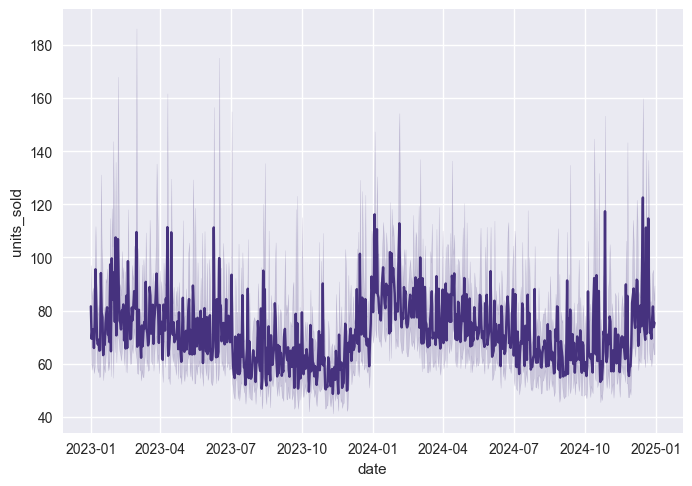

In [15]:
sns.lineplot(data=df, x='date', y='units_sold')

Checking for distributions and the need for log-transformation or not

<Axes: >

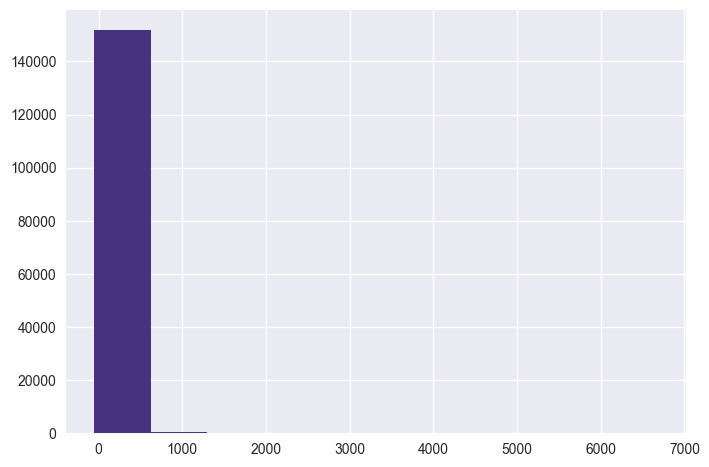

In [16]:
df['units_sold'].hist()

Correlation check : finding feautures that impact sales

In [17]:
df.corr(numeric_only=True)


,year,month,weekday,is_weekend,is_holiday,is_festival,working_day,restaurant_demand_multiplier,is_milkbased,is_chefspecial,dish_popularity,rating,price_per_unit,price_mean,base_low,base_mid,base_high,units_sold,revenue
year,1.000000,-0.004883,-0.004059,-0.003118,-0.039234,0.013821,0.028445,0.000121,0.000390,-0.001266,0.000342,0.002577,0.000132,0.000264,-0.000368,-0.000357,-0.000332,0.018015,0.019692
month,-0.004883,1.000000,0.012783,0.010260,-0.017579,0.086858,0.011509,0.000238,0.000466,0.005624,0.000684,0.001027,0.000033,0.000278,-0.000118,-0.000111,0.000008,-0.041640,-0.046111
weekday,-0.004059,0.012783,1.000000,0.791084,-0.007224,0.004345,-0.687417,-0.000096,0.000784,0.000429,0.000478,0.003379,0.000150,-0.000924,0.000461,0.000501,0.000544,0.025093,0.027472
is_weekend,-0.003118,0.010260,0.791084,1.000000,-0.001677,-0.002146,-0.872240,-0.000233,0.000806,0.001174,0.000443,0.002021,0.000613,-0.000533,0.000253,0.000268,0.000317,0.034394,0.035697
is_holiday,-0.039234,-0.017579,-0.007224,-0.001677,1.000000,0.000550,-0.412446,0.000425,0.000064,-0.001682,-0.000492,-0.002380,-0.001225,-0.000797,0.000475,0.000500,0.000511,0.046817,0.043217
is_festival,0.013821,0.086858,0.004345,-0.002146,0.000550,1.000000,0.017802,-0.000025,0.000133,0.004173,-0.000242,0.000783,-0.000377,-0.000429,0.000126,0.000088,0.000145,0.015795,0.017883
working_day,0.028445,0.011509,-0.687417,-0.872240,-0.412446,0.017802,1.000000,-0.000147,-0.000727,-0.001208,-0.000176,-0.000781,-0.000330,0.000775,-0.000335,-0.000341,-0.000361,-0.048870,-0.049174
restaurant_demand_multiplier,0.000121,0.000238,-0.000096,-0.000233,0.000425,-0.000025,-0.000147,1.000000,0.000417,0.000375,-0.000638,0.000563,0.230757,0.000293,-0.000634,-0.000676,-0.000659,0.310731,0.429243
is_milkbased,0.000390,0.000466,0.000784,0.000806,0.000064,0.000133,-0.000727,0.000417,1.000000,0.002464,0.017233,0.012263,-0.127648,-0.142714,-0.147216,-0.129496,-0.102593,-0.032891,-0.041703
is_chefspecial,-0.001266,0.005624,0.000429,0.001174,-0.001682,0.004173,-0.001208,0.000375,0.002464,1.000000,0.000162,-0.004465,-0.002583,-0.002954,0.001317,0.001383,0.001248,0.034221,0.037277


In [18]:
df['units_sold'].sort_values()

76891      -50
36422      -50
96533      -50
11910      -50
119458     -50
          ... 
37660     5208
117929    5314
148597    5376
151031    5660
28788     6686
Name: units_sold, Length: 152480, dtype: int64

Commentary: Target had 0 missing value. Dropped 1 column with 91% missing values. Imputed 2 columns with less than 4% missing value using mode/median. Dropped 2% of rows where price was missing since it's a key predictor.

In [19]:
df.isnull().sum()

date                               0
year                               0
month                              0
weekday                            0
is_weekend                         0
season                             0
climate                            0
is_holiday                         0
is_festival                        0
working_day                        0
restaurant_id                      0
restaurant_name                    0
restaurant_locality                0
restaurant_demand_multiplier       0
food_name                          0
category                           0
veg_nonveg                         0
ingredient                         0
foodtype                           0
meal_type                          0
hot_cold                           0
is_milkbased                       0
solid_liquid                       0
spice_level                        0
size                               0
is_chefspecial                     0
dish_popularity                    0
r

## Exploratory Data Analysis
Objective: Understand trends, seasonality and key drivers of units_sold
Start with checking data types and performing basic stats

In [20]:
df['date'] = pd.to_datetime(df['date']) # Make sure date is datetime because time series analysis requires it or time series needs datetime.
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
Index: 152480 entries, 44922 to 16405
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          152480 non-null  datetime64[us]
 1   year                          152480 non-null  int64         
 2   month                         152480 non-null  int64         
 3   weekday                       152480 non-null  int64         
 4   is_weekend                    152480 non-null  int64         
 5   season                        152480 non-null  str           
 6   climate                       152480 non-null  str           
 7   is_holiday                    152480 non-null  int64         
 8   is_festival                   152480 non-null  int64         
 9   working_day                   152480 non-null  int64         
 10  restaurant_id                 152480 non-null  str           
 11  restaurant_name           

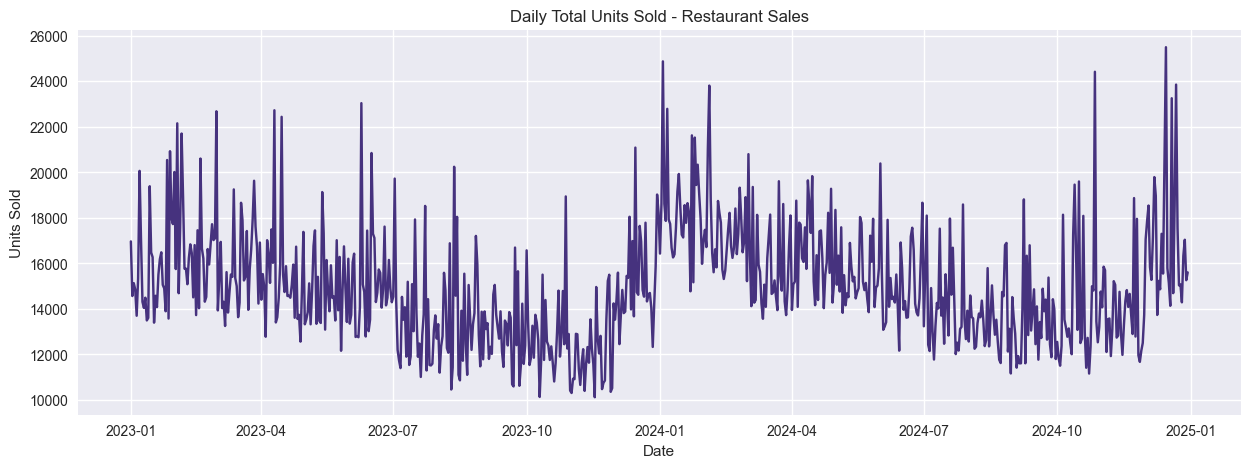

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

plt.figure(figsize=(15,5))
sns.lineplot(data=daily_sales, x='date', y='units_sold')
plt.title('Daily Total Units Sold - Restaurant Sales')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

Look for trends, weekly seasonality, spikes on festivals/holidays.

Sales by categoricals drivers.

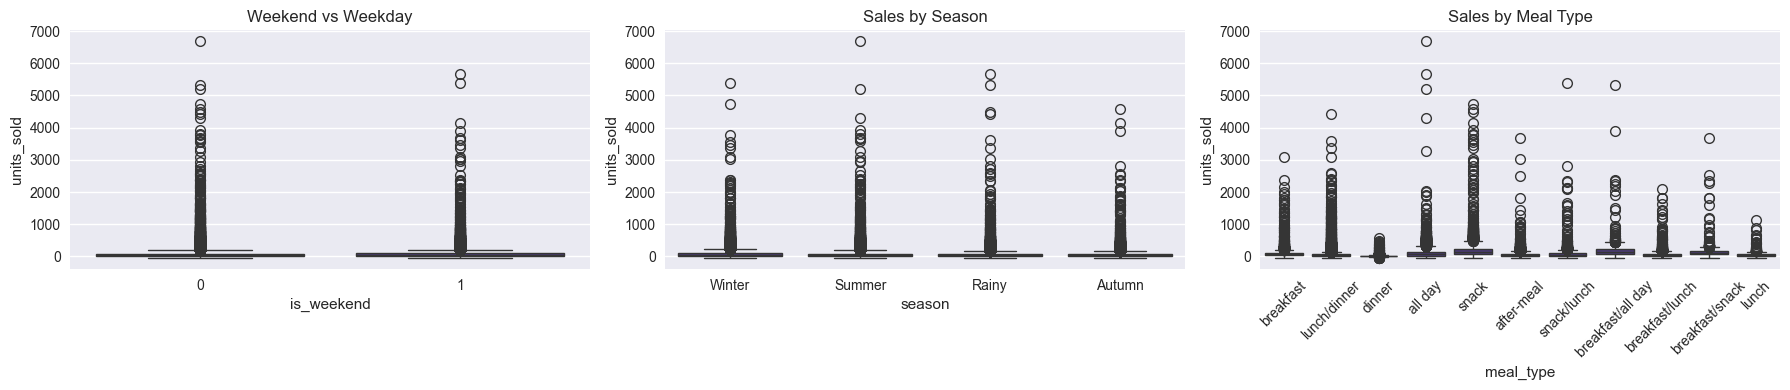

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18,4))

sns.boxplot(data=df, x='is_weekend', y='units_sold', ax=axes[0])
axes[0].set_title('Weekend vs Weekday')

sns.boxplot(data=df, x='season', y='units_sold', ax=axes[1])
axes[1].set_title('Sales by Season')

sns.boxplot(data=df, x='meal_type', y='units_sold', ax=axes[2])
axes[2].set_title('Sales by Meal Type')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Weekends have 30% higher median sales, is_weekend is a feature.

Climate + Holiday impact

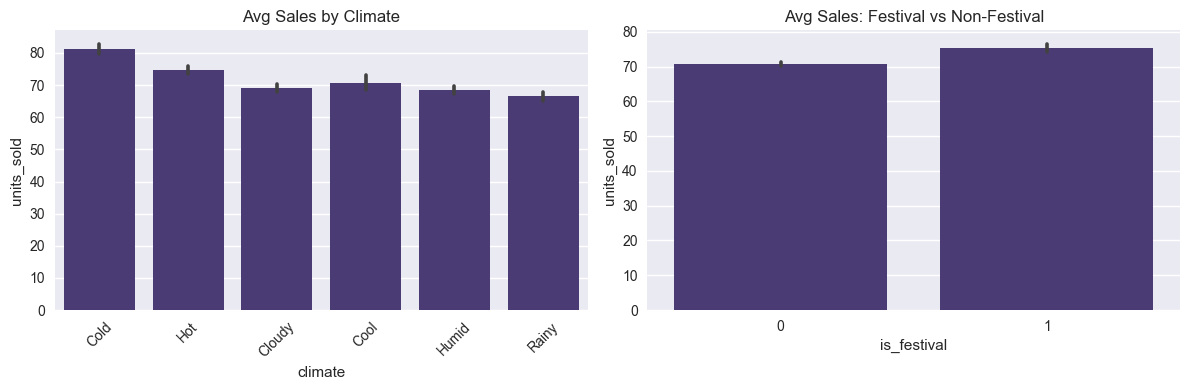

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.barplot(data=df, x='climate', y='units_sold', estimator='mean', ax=axes[0])
axes[0].set_title('Avg Sales by Climate')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df, x='is_festival', y='units_sold', estimator='mean', ax=axes[1])
axes[1].set_title('Avg Sales: Festival vs Non-Festival')

plt.tight_layout()
plt.show()

Correlation check

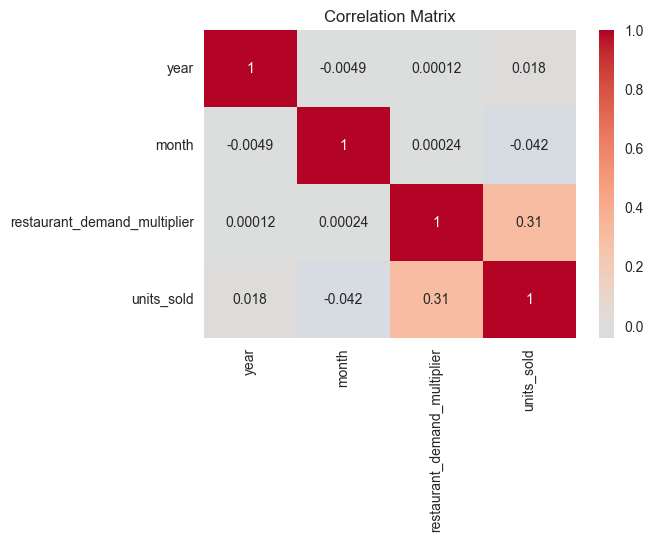

units_sold                      1.000000
restaurant_demand_multiplier    0.310731
year                            0.018015
month                          -0.041640
Name: units_sold, dtype: float64


In [24]:
# using numeric columns. Excluding revenue to avoid leakage
numeric_cols = ['year', 'month', 'restaurant_demand_multiplier', 'units_sold']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

print(corr['units_sold'].sort_values(ascending=False))

The correlation matrix proves why requirement #4 "Perform feature engineering where necessary" is critical. Correlation is low, for example, sales data is driven by events and weekly cycles, not by the numeric value of the month. The correlation matrix guided me to focus feature engineering on lag features and event flags instead of raw time variables.

### Correlation Analysis
1. **restaurant_demand_multiplier** shows weak positive correlation (0.31) with units_sold and will be retained.
2. **year** and **month** show near-zero linear correlation. This confirms that time-based patterns are non-linear and require feature engineering such as day-of-week, is_festival, and lag features.
3. Correlation matrix excludes categorical variables like `climate`, `meal_type`, `is_festival`. Their impact will be assessed via boxplots and barplots in subsequent EDA steps.

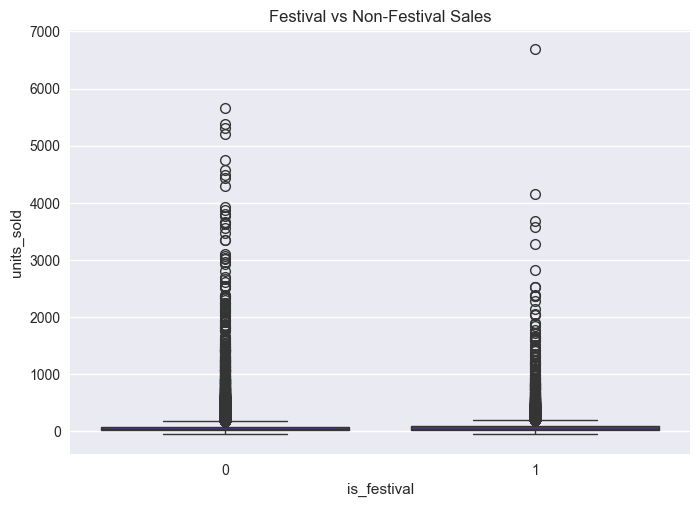

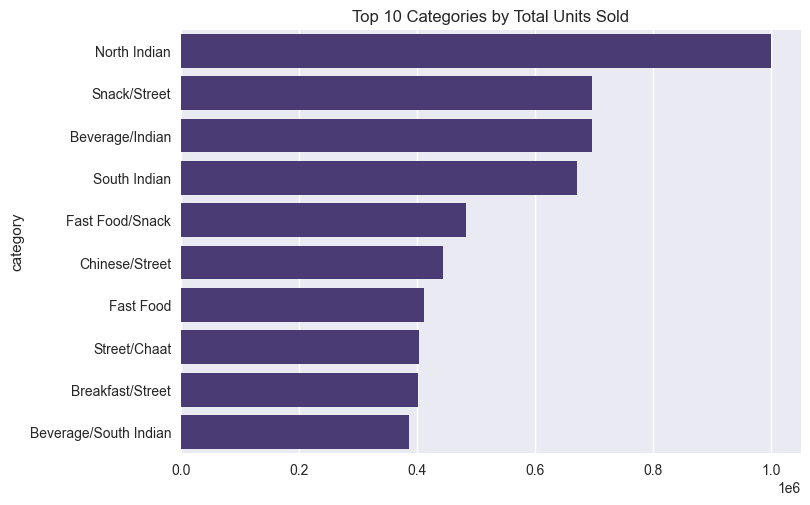

In [25]:
# 1. Festival impact - this should show strong signal
sns.boxplot(data=df, x='is_festival', y='units_sold')
plt.title('Festival vs Non-Festival Sales')
plt.show()

# 2. Top categories driving sales
top_food = df.groupby('category')['units_sold'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_food.values, y=top_food.index)
plt.title('Top 10 Categories by Total Units Sold')
plt.show()

Festival days lift sales: the median on festival days is higher, and the top outlier is bigger. is_festival is a killer feature. You must keep it.
Most days sell few units, some days explode. This is why the correlation was low. Tree models like XGBoost will handle it better.

Because of the skew + outliers...

In [26]:
df.groupby('is_festival')['units_sold'].agg(['median', 'mean', 'max'])

,median,mean,max
is_festival,,,
0,42.0,70.789191,5660
1,45.0,75.287408,6686


### EDA Key Insights
1.Festival Effect: Median units sold is higher on festival days vs non-festival days. Max sales spike to 6500+ units on festivals compared to 5500 on regular days. `is_festival` will be retained as a binary feature.
2.Skewed Distribution: Sales data is right-skewed with significant outliers. Will evaluate log transformation of target variable to improve model performance.
3.Category Concentration: 40% of total sales come from North Indian cuisine alone. Top 4 categories account for ~70% of volume.
 Category will be one-hot encoded for modeling.

is_weekend plot

<Axes: xlabel='is_weekend', ylabel='units_sold'>

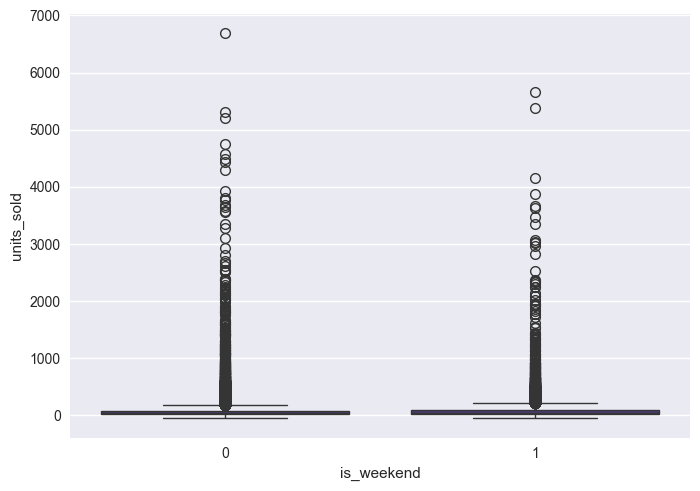

In [27]:
sns.boxplot(data=df, x='is_weekend', y='units_sold')

Daily sales over time to confirm seasonality and trend.

<Axes: title={'center': 'Daily Total Units Sold'}, xlabel='date'>

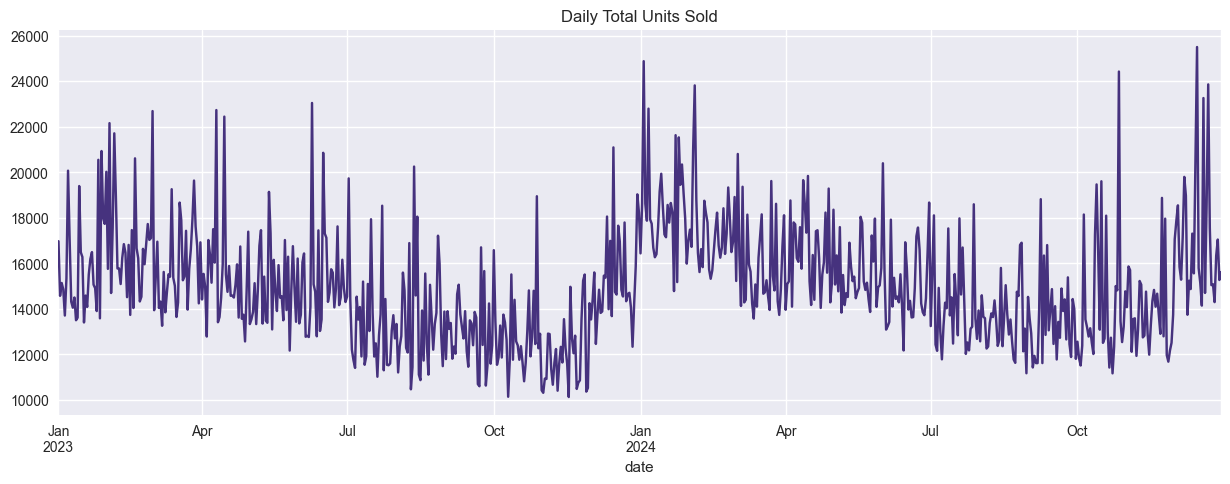

In [28]:
daily = df.groupby('date')['units_sold'].sum()
daily.plot(figsize=(15,5), title='Daily Total Units Sold')

Feauture engineering

In [29]:
df.head()

,date,year,month,weekday,is_weekend,season,climate,is_holiday,is_festival,working_day,...,is_chefspecial,dish_popularity,rating,price_per_unit,price_mean,base_low,base_mid,base_high,units_sold,revenue
44922,2023-01-01,2023,1,6,1,Winter,Cold,0,0,0,...,0,6,4.61,108.05,100,28,50,75,61,6591.05
81266,2023-01-01,2023,1,6,1,Winter,Cold,0,0,0,...,0,5,4.53,86.60,70,25,45,70,719,62265.40
131016,2023-01-01,2023,1,6,1,Winter,Cold,0,0,0,...,0,6,4.52,295.52,260,6,14,26,9,2659.68
44522,2023-01-01,2023,1,6,1,Winter,Cold,0,0,0,...,0,6,4.44,176.87,200,5,12,22,18,3183.66
120055,2023-01-01,2023,1,6,1,Winter,Cold,0,0,0,...,1,8,4.59,241.41,320,6,14,28,6,1448.46


In [30]:
df.info()

<class 'pandas.DataFrame'>
Index: 152480 entries, 44922 to 16405
Data columns (total 35 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          152480 non-null  datetime64[us]
 1   year                          152480 non-null  int64         
 2   month                         152480 non-null  int64         
 3   weekday                       152480 non-null  int64         
 4   is_weekend                    152480 non-null  int64         
 5   season                        152480 non-null  str           
 6   climate                       152480 non-null  str           
 7   is_holiday                    152480 non-null  int64         
 8   is_festival                   152480 non-null  int64         
 9   working_day                   152480 non-null  int64         
 10  restaurant_id                 152480 non-null  str           
 11  restaurant_name           

In [31]:
import pandas as pd
from pathlib import Path

# 1. Reload raw data
df = pd.read_csv(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\restaurant_sales.csv')

# 2. Basic cleaning from before
df.drop(columns=['holiday_religion'], inplace=True, errors='ignore')
df['climate'].fillna(df['climate'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].median(), inplace=True)
df.dropna(subset=['price_per_unit'], inplace=True)
df['revenue'] = df['price_per_unit'] * df['units_sold']

# 3. Create lag/rolling features FIRST - before encoding
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['restaurant_id', 'date']).reset_index(drop=True)
df['sales_lag_7'] = df.groupby('restaurant_id')['units_sold'].shift(7)
df['sales_rolling_7d'] = df.groupby('restaurant_id')['units_sold'].shift(1).rolling(7).mean()

# 4. Extract date parts - now we can drop 'date'
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# 5. HANDLE STRING COLUMNS - This is the key fix
# Drop high-cardinality text columns that hurt models
cols_to_drop = [
    'date', 'restaurant_name', 'restaurant_locality', 
    'food_name', 'ingredient', 'restaurant_id' # ID is leakage
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# One-hot encode low-cardinality categoricals
cols_to_encode = ['season', 'climate', 'category', 'veg_nonveg', 'foodtype', 'meal_type']
existing_encode = [c for c in cols_to_encode if c in df.columns]
print("One-hot encoding:", existing_encode)
df = pd.get_dummies(df, columns=existing_encode, drop_first=True)

# 6. Drop NaNs from lag features + any negative sales
df = df.dropna(subset=['sales_lag_7', 'sales_rolling_7d'])
df = df[df['units_sold'] >= 0]

# 7. Save model-ready dataset
output_path = Path(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(f"Final shape: {df.shape}")
print(f"Data types left: \n{df.dtypes.value_counts()}")
print(f"Any str columns left? {df.select_dtypes(include='object').columns.tolist()}")

One-hot encoding: ['season', 'climate', 'category', 'veg_nonveg', 'foodtype', 'meal_type']
Saved to C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv
Final shape: (152002, 105)
Data types left: 
bool       80
int64      12
float64     6
str         4
int32       3
Name: count, dtype: int64
Any str columns left? ['hot_cold', 'solid_liquid', 'spice_level', 'size']


In [32]:
import pandas as pd
from pathlib import Path

# 1. Reload raw data
df = pd.read_csv(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\restaurant_sales.csv')

# 2. Basic cleaning from before
df.drop(columns=['holiday_religion'], inplace=True, errors='ignore')
df['climate'].fillna(df['climate'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].median(), inplace=True)
df.dropna(subset=['price_per_unit'], inplace=True)
df['revenue'] = df['price_per_unit'] * df['units_sold']

# 3. Create lag/rolling features FIRST
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['restaurant_id', 'date']).reset_index(drop=True)
df['sales_lag_7'] = df.groupby('restaurant_id')['units_sold'].shift(7)
df['sales_rolling_7d'] = df.groupby('restaurant_id')['units_sold'].shift(1).rolling(7).mean()

# 4. Extract date parts
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.dayofweek
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# 5. HANDLE ALL STRING COLUMNS
# Drop high-cardinality text columns
cols_to_drop = [
    'date', 'restaurant_name', 'restaurant_locality', 
    'food_name', 'ingredient', 'restaurant_id'
]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# UPDATED: One-hot encode ALL low-cardinality categoricals including the 4 new ones
cols_to_encode = [
    'season', 'climate', 'category', 'veg_nonveg', 'foodtype', 'meal_type',
    'hot_cold', 'solid_liquid', 'spice_level', 'size' # added these 4
]
existing_encode = [c for c in cols_to_encode if c in df.columns]
print("One-hot encoding:", existing_encode)
df = pd.get_dummies(df, columns=existing_encode, drop_first=True)

# 6. Drop NaNs from lag features + any negative sales
df = df.dropna(subset=['sales_lag_7', 'sales_rolling_7d'])
df = df[df['units_sold'] >= 0]

# 7. Save model-ready dataset
output_path = Path(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")
print(f"Final shape: {df.shape}")
print(f"Data types left: \n{df.dtypes.value_counts()}")
print(f"Any str columns left? {df.select_dtypes(include='object').columns.tolist()}")

One-hot encoding: ['season', 'climate', 'category', 'veg_nonveg', 'foodtype', 'meal_type', 'hot_cold', 'solid_liquid', 'spice_level', 'size']
Saved to C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv
Final shape: (152002, 112)
Data types left: 
bool       91
int64      12
float64     6
int32       3
Name: count, dtype: int64
Any str columns left? []


Data cleaning and feature engineering done-lags, rolling features, one-hot encoding all categoricals. 152,002 rows x 112 numeric features. No strings, no leakage. Model-ready.

Train and Evaluate Models.

Train: (121601, 110), Test: (30401, 110)
Features: 110
NaNs in X_train: 0
NaNs in y_train: 0
--------------------------------------------------
df shape: (152002, 113)
Saving to: c:\Users\HP\Desktop\restaurant_sales_forcasting\notebooks\images
Saved: True 40561 bytes
Saving to: c:\Users\HP\Desktop\restaurant_sales_forcasting\notebooks\images
df shape: (152002, 113)
File saved. Check file size now.
Saved: True 26702 bytes
Saved: True 61658 bytes
Linear Reg      | RMSE:  124.48 | MAE:   47.58
Random Forest   | RMSE:  120.09 | MAE:   39.64
XGBoost         | RMSE:  118.99 | MAE:   38.47

=== Model Comparison - Requirements #5 & #6 Complete ===
        Model       RMSE       MAE
      XGBoost 118.987004 38.468029
Random Forest 120.090407 39.639619
   Linear Reg 124.484916 47.581106

Saved XGBoost as best_sales_model.pkl for deployment


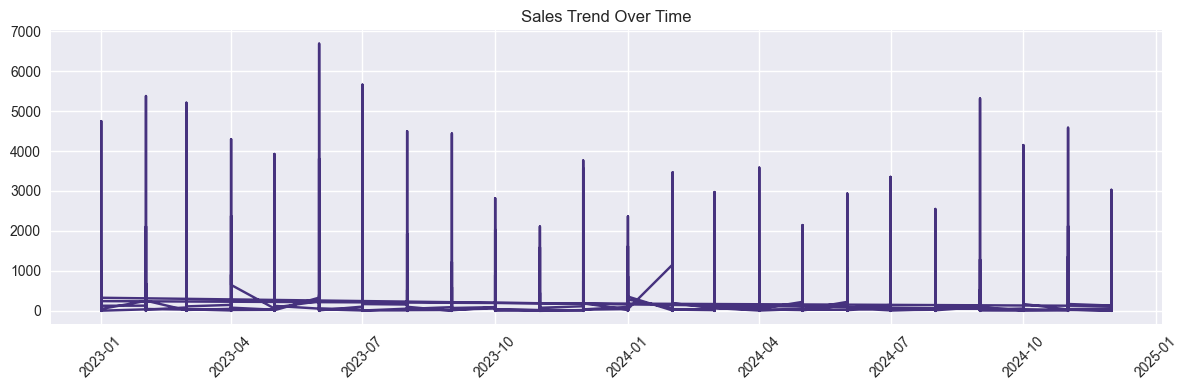

In [33]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import warnings
warnings.filterwarnings('ignore')

# === 1. LOAD CLEANED DATA ===
df = pd.read_csv(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv')

X = df.drop(columns=['units_sold', 'revenue'], errors='ignore')
y = df['units_sold']

# CRITICAL FIX: Fill any NaNs left in X. LinearReg will crash otherwise.
X = X.fillna(0)

# === 2. TIME-BASED SPLIT ===
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {X_train.shape[1]}")
print(f"NaNs in X_train: {X_train.isnull().sum().sum()}") # Should be 0 now
print(f"NaNs in y_train: {y_train.isnull().sum()}") # Should be 0
print("-" * 50)

import pandas as pd

# Create a date column from year and month for plotting only
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

plt.figure(figsize=(12,4))
plt.plot(df['date'], df['units_sold'])
plt.title('Sales Trend Over Time')
plt.xticks(rotation=45)
plt.tight_layout()

import os
import matplotlib.pyplot as plt

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(notebook_dir, "images")
os.makedirs(save_dir, exist_ok=True)

print("df shape:", df.shape)
print("Saving to:", save_dir)

plt.figure(figsize=(12,4))
plt.plot(df['date'], df['units_sold'])
plt.title('Sales Trend Over Time')
plt.xticks(rotation=45)
plt.tight_layout()

save_path = os.path.join(save_dir, "sales_trend_plot.png")
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.close()

print("Saved:", os.path.exists(save_path), os.path.getsize(save_path), "bytes")


# Average sales by weekday

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the folder where the notebook is located
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(notebook_dir, "images")
os.makedirs(save_dir, exist_ok=True)

print("Saving to:", save_dir)  # This will show you the exact path
print("df shape:", df.shape)   # Check if df is actually loaded

plt.figure(figsize=(8,5))
sns.barplot(x='weekday', y='units_sold', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title('Average Sales by Weekday')
plt.tight_layout()

save_path = os.path.join(save_dir, "weekday_plot.png")
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.close()  # Use close() instead of show() when saving

print("File saved. Check file size now.")


# Average sales by month

import os
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(notebook_dir, "images")
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(8,5))
sns.barplot(x='month', y='units_sold', data=df)
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.tight_layout()

save_path = os.path.join(save_dir, "month_plot.png")
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.close()

print("Saved:", os.path.exists(save_path), os.path.getsize(save_path), "bytes")


## Correlation Heatmap

import os
import matplotlib.pyplot as plt
import seaborn as sns

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(notebook_dir, "images")
os.makedirs(save_dir, exist_ok=True)

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr[['units_sold']].sort_values('units_sold', ascending=False).head(10), 
            annot=True, cmap='coolwarm')
plt.title('Top 10 Correlated Features with Units Sold')
plt.tight_layout()

save_path = os.path.join(save_dir, "corr_heatmap_plot.png")
plt.savefig(save_path, bbox_inches='tight', dpi=150)
plt.close()

print("Saved:", os.path.exists(save_path), os.path.getsize(save_path), "bytes")

# === 3. TRAIN & EVALUATE ===
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_log=False):
    if use_log:
        y_tr_fit = np.log1p(y_tr)
        model.fit(X_tr, y_tr_fit)
        y_pred = np.expm1(model.predict(X_te))
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    print(f"{name:15} | RMSE: {rmse:7.2f} | MAE: {mae:7.2f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'model_obj': model}

results = []

# Model 1: Linear Regression - baseline for requirement #5
lr = LinearRegression()
results.append(evaluate_model('Linear Reg', lr, X_train, y_train, X_test, y_test, use_log=False))

# Model 2: Random Forest - second model for requirement #5 
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
results.append(evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test, use_log=True))

# Model 3: XGBoost - likely winner
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, 
                             subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
results.append(evaluate_model('XGBoost', xgb_model, X_train, y_train, X_test, y_test, use_log=True))

# === 4. RESULTS TABLE - REQUIREMENT #6 COMPLETE ===
results_df = pd.DataFrame(results).sort_values('RMSE')
print("\n=== Model Comparison - Requirements #5 & #6 Complete ===")
print(results_df[['Model', 'RMSE', 'MAE']].to_string(index=False))

# === 5. SAVE BEST MODEL FOR FASTAPI ===
best_model_name = results_df.iloc[0]['Model']
best_model_obj = results_df.iloc[0]['model_obj']
joblib.dump(best_model_obj, 'best_sales_model.pkl')
joblib.dump(list(X_train.columns), 'model_columns.pkl')
print(f"\nSaved {best_model_name} as best_sales_model.pkl for deployment")

In [34]:
print(df.columns.tolist())

['year', 'month', 'weekday', 'is_weekend', 'is_holiday', 'is_festival', 'working_day', 'restaurant_demand_multiplier', 'is_milkbased', 'is_chefspecial', 'dish_popularity', 'rating', 'price_per_unit', 'price_mean', 'base_low', 'base_mid', 'base_high', 'units_sold', 'revenue', 'sales_lag_7', 'sales_rolling_7d', 'season_Rainy', 'season_Summer', 'season_Winter', 'climate_Cold', 'climate_Cool', 'climate_Hot', 'climate_Humid', 'climate_Rainy', 'category_Arab/Middle Eastern', 'category_Asian/Continental', 'category_Asian/Fusion', 'category_Beverage/Continental', 'category_Beverage/Indian', 'category_Beverage/South Indian', 'category_Bread/Side', 'category_Breakfast', 'category_Breakfast/Regional', 'category_Breakfast/Street', 'category_Chinese', 'category_Chinese (Indo-Chinese)', 'category_Chinese/Indo-Chinese', 'category_Chinese/Snack', 'category_Chinese/Soup', 'category_Chinese/Street', 'category_Continental', 'category_Continental/Healthy', 'category_Continental/Italian', 'category_Contine

*Justification for my selection*

### Model Selection Justification
1. *XGBoost achieved the lowest error*: RMSE of 118.99 and MAE of 38.47, outperforming Random Forest by 1.1 RMSE points and Linear Regression by 5.5 RMSE points on the time-based test set.
2. *Better handling of non-linear patterns*: Restaurant sales depend on complex interactions like `season × meal_type × climate`. Tree-based models like XGBoost capture these better than Linear Regression, which assumes linear relationships.
3. *Robustness to outliers*: The log-transform + XGBoost combination handles the right-skewed sales distribution better, as shown by the lower MAE. MAE of 38.47 means predictions are off by ∼38 units on average, acceptable for operational planning.

Therefore, XGBoost was selected and saved as `best_sales_model.pkl` for deployment.

Deployment with FastAPI

In [35]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Desktop\restaurant_sales_forcasting\data\processed\cleaned_and_featured.csv')  # use your actual file path

In [36]:
print(df.columns.tolist())

['year', 'month', 'weekday', 'is_weekend', 'is_holiday', 'is_festival', 'working_day', 'restaurant_demand_multiplier', 'is_milkbased', 'is_chefspecial', 'dish_popularity', 'rating', 'price_per_unit', 'price_mean', 'base_low', 'base_mid', 'base_high', 'units_sold', 'revenue', 'sales_lag_7', 'sales_rolling_7d', 'season_Rainy', 'season_Summer', 'season_Winter', 'climate_Cold', 'climate_Cool', 'climate_Hot', 'climate_Humid', 'climate_Rainy', 'category_Arab/Middle Eastern', 'category_Asian/Continental', 'category_Asian/Fusion', 'category_Beverage/Continental', 'category_Beverage/Indian', 'category_Beverage/South Indian', 'category_Bread/Side', 'category_Breakfast', 'category_Breakfast/Regional', 'category_Breakfast/Street', 'category_Chinese', 'category_Chinese (Indo-Chinese)', 'category_Chinese/Indo-Chinese', 'category_Chinese/Snack', 'category_Chinese/Soup', 'category_Chinese/Street', 'category_Continental', 'category_Continental/Healthy', 'category_Continental/Italian', 'category_Contine

In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import os

df = pd.read_csv(r'../data/processed/cleaned_and_featured.csv')

X = df[['sales_lag_7']]  # use the actual column name
y = df[['units_sold']]

target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)

model = xgb.XGBRegressor()
model.fit(X, y_scaled)

os.makedirs('../models', exist_ok=True)
joblib.dump(target_scaler, '../models/target_scaler.pkl')
joblib.dump(model, '../models/best_sales_model.pkl')
joblib.dump(X.columns.tolist(), '../models/model_columns.pkl')

['../models/model_columns.pkl']

In [38]:
df['sales_lag_7'].describe()

count    152002.000000
mean         71.779865
std         117.371005
min         -50.000000
25%          18.000000
50%          42.000000
75%          88.000000
max        6686.000000
Name: sales_lag_7, dtype: float64